# 🎯 eBay Auction Price Prediction - EDA

**Goal:** Build an ML model that predicts optimal starting prices for auction listings

**Core Features:**
- Predict final sale price given item details
- Recommend optimal opening bid (starting price)
- LLM explains the reasoning behind recommendations

**Dataset:** eBay auction data (Cartier watches, Palm PDAs, Xbox, Swarovski beads)

---

## 📥 Setup

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

print("✓ Libraries loaded!")

✓ Libraries loaded!


In [ ]:
# Upload auction.csv
from google.colab import files
uploaded = files.upload()
print("✓ File uploaded!")

✓ File uploaded!


In [ ]:
# Load data
df = pd.read_csv('auction.csv')

print("="*80)
print("DATA LOADED")
print("="*80)
print(f"Shape: {df.shape[0]:,} bids × {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")

DATA LOADED
Shape: 10,681 bids × 9 columns

Columns: ['auctionid', 'bid', 'bidtime', 'bidder', 'bidderrate', 'openbid', 'price', 'item', 'auction_type']


---
## 1️⃣ Understanding the Data

In [ ]:
# Data overview
print("First 10 rows:")
df.head(10)

First 10 rows:


,auctionid,bid,bidtime,bidder,bidderrate,openbid,price,item,auction_type
0,1638893549,175.00,2.230949,schadenfreud,0.0,99.0,177.5,Cartier wristwatch,3 day auction
1,1638893549,100.00,2.600116,chuik,0.0,99.0,177.5,Cartier wristwatch,3 day auction
2,1638893549,120.00,2.600810,kiwisstuff,2.0,99.0,177.5,Cartier wristwatch,3 day auction
3,1638893549,150.00,2.601076,kiwisstuff,2.0,99.0,177.5,Cartier wristwatch,3 day auction
4,1638893549,177.50,2.909826,eli.flint@flightsafety.co,4.0,99.0,177.5,Cartier wristwatch,3 day auction
5,1639453840,1.00,0.355856,bfalconb,2.0,1.0,355.0,Cartier wristwatch,3 day auction
6,1639453840,1.25,0.484757,sbord,1.0,1.0,355.0,Cartier wristwatch,3 day auction
7,1639453840,1.50,0.492639,bfalconb,2.0,1.0,355.0,Cartier wristwatch,3 day auction
8,1639453840,25.00,0.494630,sbord,1.0,1.0,355.0,Cartier wristwatch,3 day auction
9,1639453840,2.00,0.511169,bfalconb,2.0,1.0,355.0,Cartier wristwatch,3 day auction


In [ ]:
# Data types and missing values
print("Data Info:")
print("="*80)
df.info()

print("\nMissing Values:")
print("="*80)
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("✓ No missing values!")

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10681 entries, 0 to 10680
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   auctionid     10681 non-null  int64  
 1   bid           10681 non-null  float64
 2   bidtime       10681 non-null  float64
 3   bidder        10665 non-null  object 
 4   bidderrate    10670 non-null  float64
 5   openbid       10681 non-null  float64
 6   price         10681 non-null  float64
 7   item          10681 non-null  object 
 8   auction_type  10681 non-null  object 
dtypes: float64(5), int64(1), object(3)
memory usage: 751.1+ KB

Missing Values:
bidder        16
bidderrate    11
dtype: int64


In [ ]:
# Basic statistics
print("Descriptive Statistics:")
df.describe()

Descriptive Statistics:


,auctionid,bid,bidtime,bidderrate,openbid,price
count,1.068100e+04,10681.000000,10681.000000,10670.000000,10681.000000,10681.000000
mean,4.136148e+09,207.586109,3.979628,31.936739,52.246256,335.043589
std,2.489918e+09,323.037396,2.353386,120.594074,168.453245,433.566009
min,1.638844e+09,0.010000,0.000567,-4.000000,0.010000,26.000000
25%,3.015329e+09,72.000000,1.949931,1.000000,1.000000,186.510000
50%,3.020526e+09,140.000000,4.140833,5.000000,4.990000,228.490000
75%,8.212136e+09,210.000000,6.448060,21.000000,50.000000,255.000000
max,8.215611e+09,5400.000000,6.999990,3140.000000,5000.000000,5400.000000


---
## 2️⃣ Create Auction-Level Dataset (One Row Per Auction)

Currently each row is a **bid**. We need to aggregate to **auction level** for price prediction.

In [ ]:
# Aggregate to auction level
print("Creating auction-level dataset...")

auctions = df.groupby('auctionid').agg({
    'bid': 'count',              # Total number of bids
    'bidder': 'nunique',          # Number of unique bidders
    'bidderrate': 'mean',         # Average bidder reputation
    'openbid': 'first',           # Opening bid (same for all bids in auction)
    'price': 'first',             # Final price (same for all bids in auction)
    'item': 'first',              # Item category
    'auction_type': 'first'       # Auction type
}).reset_index()

# Rename columns for clarity
auctions.columns = ['auctionid', 'total_bids', 'unique_bidders', 'avg_bidder_rating',
                    'opening_bid', 'final_price', 'item', 'auction_type']

# Add key derived features
auctions['price_increase'] = auctions['final_price'] - auctions['opening_bid']
auctions['price_increase_pct'] = (auctions['price_increase'] / auctions['opening_bid'] * 100)
auctions['competition_intensity'] = auctions['total_bids'] / auctions['unique_bidders']

print(f"\n✓ Created dataset: {len(auctions):,} auctions")
print(f"✓ Features: {list(auctions.columns)}")

auctions.head(10)

Creating auction-level dataset...

✓ Created dataset: 628 auctions
✓ Features: ['auctionid', 'total_bids', 'unique_bidders', 'avg_bidder_rating', 'opening_bid', 'final_price', 'item', 'auction_type', 'price_increase', 'price_increase_pct', 'competition_intensity']


,auctionid,total_bids,unique_bidders,avg_bidder_rating,opening_bid,final_price,item,auction_type,price_increase,price_increase_pct,competition_intensity
0,1638843936,7,5,38.428571,500.0,1625.00,Cartier wristwatch,7 day auction,1125.00,225.000000,1.400000
1,1638844284,2,2,16.500000,200.0,500.00,Cartier wristwatch,7 day auction,300.00,150.000000,1.000000
2,1638844464,16,5,9.125000,300.0,740.00,Cartier wristwatch,7 day auction,440.00,146.666667,3.200000
3,1638844729,11,2,29.636364,225.0,320.00,Cartier wristwatch,7 day auction,95.00,42.222222,5.500000
4,1638893549,5,4,1.600000,99.0,177.50,Cartier wristwatch,3 day auction,78.50,79.292929,1.250000
5,1638917885,13,10,88.153846,25.0,227.50,Cartier wristwatch,7 day auction,202.50,810.000000,1.300000
6,1639226378,12,10,11.000000,495.0,1725.00,Cartier wristwatch,7 day auction,1230.00,248.484848,1.200000
7,1639253454,2,2,4.500000,250.0,255.00,Cartier wristwatch,7 day auction,5.00,2.000000,1.000000
8,1639309309,27,9,8.481481,1.0,374.99,Cartier wristwatch,7 day auction,373.99,37399.000000,3.000000
9,1639323228,8,3,55.750000,1.0,185.00,Cartier wristwatch,7 day auction,184.00,18400.000000,2.666667


---
## 3️⃣ Item Categories Analysis

Understanding price differences across product categories.

In [ ]:
# Category breakdown
print("Item Categories:")
print("="*80)
print(auctions['item'].value_counts())

# Price statistics by category
print("\n\nPrice Statistics by Category:")
print("="*80)
category_stats = auctions.groupby('item').agg({
    'auctionid': 'count',
    'opening_bid': 'mean',
    'final_price': ['mean', 'median', 'min', 'max'],
    'price_increase_pct': 'mean'
}).round(2)

category_stats.columns = ['num_auctions', 'avg_opening_bid', 'avg_final_price',
                          'median_final_price', 'min_price', 'max_price', 'avg_increase_pct']
category_stats

Item Categories:
item
Palm Pilot M515 PDA    343
Xbox game console      149
Cartier wristwatch     136
Name: count, dtype: int64


Price Statistics by Category:


,num_auctions,avg_opening_bid,avg_final_price,median_final_price,min_price,max_price,avg_increase_pct
item,,,,,,,
Cartier wristwatch,136,267.02,884.56,510.00,26.0,5400.00,166648.28
Palm Pilot M515 PDA,343,77.25,229.08,231.50,175.0,290.00,421921.46
Xbox game console,149,39.32,131.41,123.15,28.0,501.77,114940.54


---
## 4️⃣ Opening Bid Strategy Analysis (KEY FOR YOUR MODEL)

**Question:** How does the opening bid affect the final price?

In [ ]:
# Correlation between opening bid and final price
correlation = auctions['opening_bid'].corr(auctions['final_price'])

print("Opening Bid vs Final Price:")
print("="*80)
print(f"Correlation: {correlation:.3f}")
print(f"\n🎯 KEY INSIGHT: {'Strong' if abs(correlation) > 0.7 else 'Moderate'} positive correlation!")
print("   → Opening bid is a STRONG predictor of final price")
print("   → This is the most important feature for your ML model")

Opening Bid vs Final Price:
Correlation: 0.643

🎯 KEY INSIGHT: Moderate positive correlation!
   → Opening bid is a STRONG predictor of final price
   → This is the most important feature for your ML model


In [ ]:
# Create opening bid categories
auctions['openbid_strategy'] = pd.cut(auctions['opening_bid'],
                                       bins=[0, 10, 50, 100, 1000],
                                       labels=['Very Low ($0-10)', 'Low ($10-50)',
                                               'Medium ($50-100)', 'High ($100+)'])

# Performance by strategy
print("\nPerformance by Opening Bid Strategy:")
print("="*80)
strategy_performance = auctions.groupby('openbid_strategy').agg({
    'auctionid': 'count',
    'final_price': 'mean',
    'total_bids': 'mean',
    'unique_bidders': 'mean',
    'price_increase_pct': 'mean'
}).round(2)

strategy_performance.columns = ['num_auctions', 'avg_final_price', 'avg_bids',
                                'avg_bidders', 'avg_increase_pct']
strategy_performance


Performance by Opening Bid Strategy:


,num_auctions,avg_final_price,avg_bids,avg_bidders,avg_increase_pct
openbid_strategy,,,,,
Very Low ($0-10),300,310.79,23.74,11.31,614834.99
Low ($10-50),66,188.76,18.38,8.64,496.51
Medium ($50-100),80,259.08,12.96,6.19,188.79
High ($100+),174,422.45,7.25,3.99,62.47


---
## 5️⃣ Competition Metrics

How bidder activity affects final prices.

In [ ]:
print("Competition Metrics:")
print("="*80)
print(f"Average bids per auction: {auctions['total_bids'].mean():.1f}")
print(f"Average unique bidders: {auctions['unique_bidders'].mean():.1f}")
print(f"Average competition intensity: {auctions['competition_intensity'].mean():.2f} bids/bidder")

# Correlation with price
print("\nCorrelation with Final Price:")
print("-"*80)
print(f"Total bids: {auctions['total_bids'].corr(auctions['final_price']):.3f}")
print(f"Unique bidders: {auctions['unique_bidders'].corr(auctions['final_price']):.3f}")
print(f"Avg bidder rating: {auctions['avg_bidder_rating'].corr(auctions['final_price']):.3f}")

Competition Metrics:
Average bids per auction: 17.0
Average unique bidders: 8.2
Average competition intensity: 2.05 bids/bidder

Correlation with Final Price:
--------------------------------------------------------------------------------
Total bids: -0.042
Unique bidders: -0.062
Avg bidder rating: -0.044


---
# 📊 VISUALIZATIONS

## 📈 Viz 1: Opening Bid vs Final Price (MOST IMPORTANT)

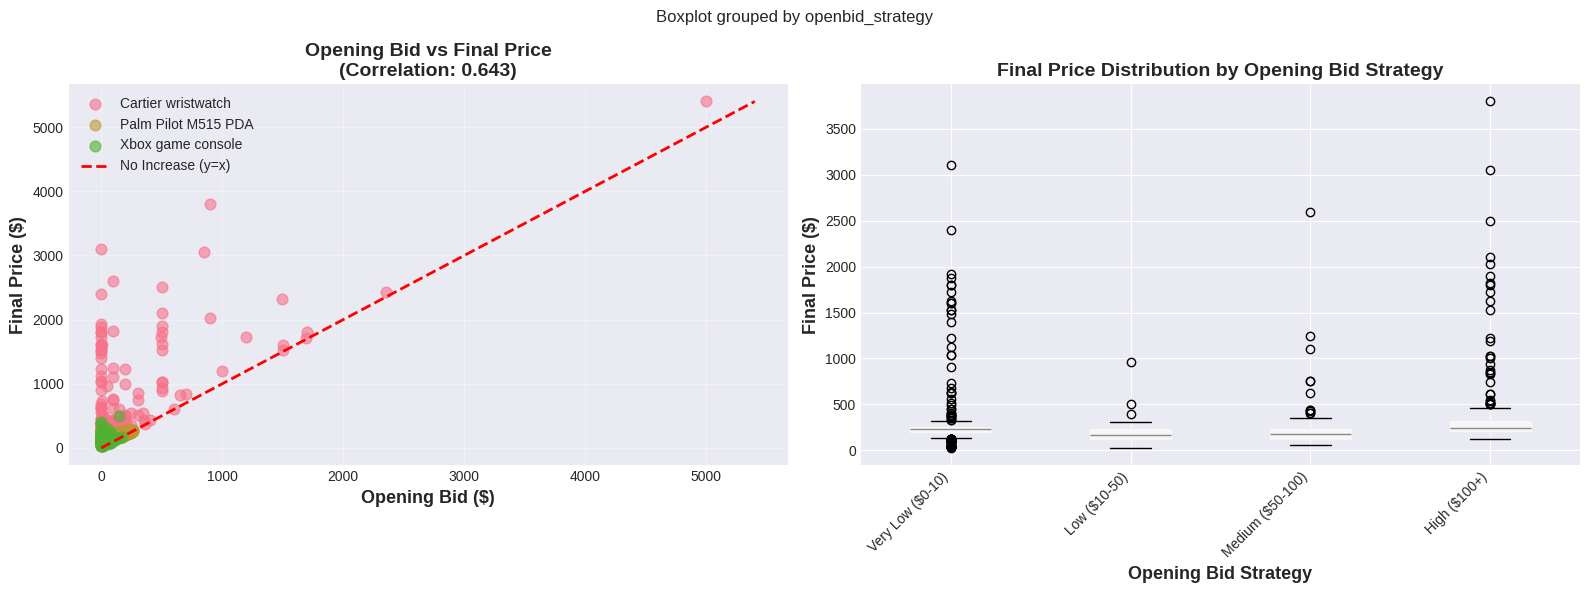


🎯 KEY TAKEAWAY: Strong positive correlation between opening bid and final price!
   → This will be the PRIMARY feature in your ML model


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot by category
ax = axes[0]
for item in auctions['item'].unique():
    item_data = auctions[auctions['item'] == item]
    ax.scatter(item_data['opening_bid'], item_data['final_price'],
               alpha=0.6, s=60, label=item)

# Add y=x reference line
max_val = max(auctions['opening_bid'].max(), auctions['final_price'].max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='No Increase (y=x)')

ax.set_xlabel('Opening Bid ($)', fontsize=13, fontweight='bold')
ax.set_ylabel('Final Price ($)', fontsize=13, fontweight='bold')
ax.set_title(f'Opening Bid vs Final Price\n(Correlation: {correlation:.3f})',
             fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Box plot by opening bid strategy
ax = axes[1]
auctions.boxplot(column='final_price', by='openbid_strategy', ax=ax, patch_artist=True)
ax.set_xlabel('Opening Bid Strategy', fontsize=13, fontweight='bold')
ax.set_ylabel('Final Price ($)', fontsize=13, fontweight='bold')
ax.set_title('Final Price Distribution by Opening Bid Strategy', fontsize=14, fontweight='bold')
plt.sca(ax)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("\n🎯 KEY TAKEAWAY: Strong positive correlation between opening bid and final price!")
print("   → This will be the PRIMARY feature in your ML model")

## 📊 Viz 2: Price Distribution by Category

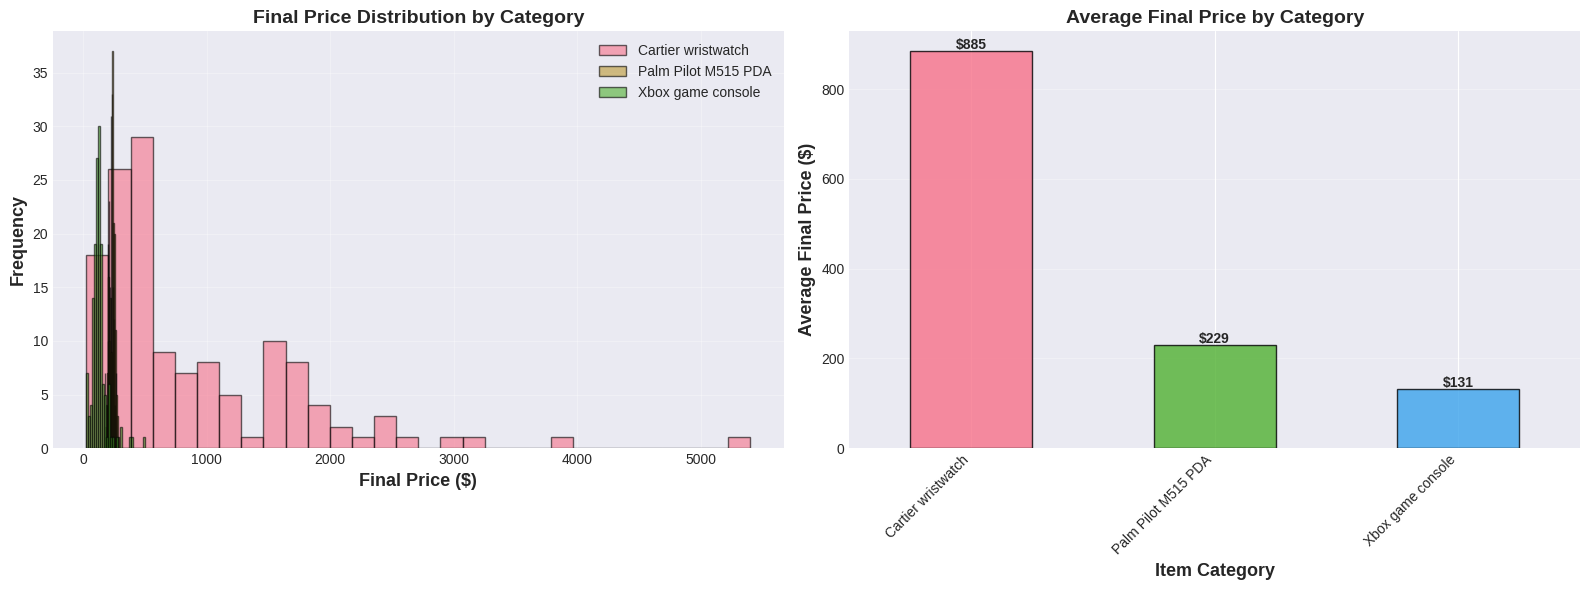

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram by category
ax = axes[0]
for item in auctions['item'].unique():
    data = auctions[auctions['item'] == item]['final_price']
    ax.hist(data, alpha=0.6, bins=30, label=item, edgecolor='black')

ax.set_xlabel('Final Price ($)', fontsize=13, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=13, fontweight='bold')
ax.set_title('Final Price Distribution by Category', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Bar chart of average prices
ax = axes[1]
avg_prices = auctions.groupby('item')['final_price'].mean().sort_values(ascending=False)
colors = sns.color_palette('husl', len(avg_prices))
avg_prices.plot(kind='bar', ax=ax, color=colors, edgecolor='black', alpha=0.8)
ax.set_xlabel('Item Category', fontsize=13, fontweight='bold')
ax.set_ylabel('Average Final Price ($)', fontsize=13, fontweight='bold')
ax.set_title('Average Final Price by Category', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')

# Add value labels
for i, v in enumerate(avg_prices):
    ax.text(i, v + 5, f'${v:.0f}', ha='center', fontweight='bold')

ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 🏆 Viz 3: Opening Bid Strategy Performance

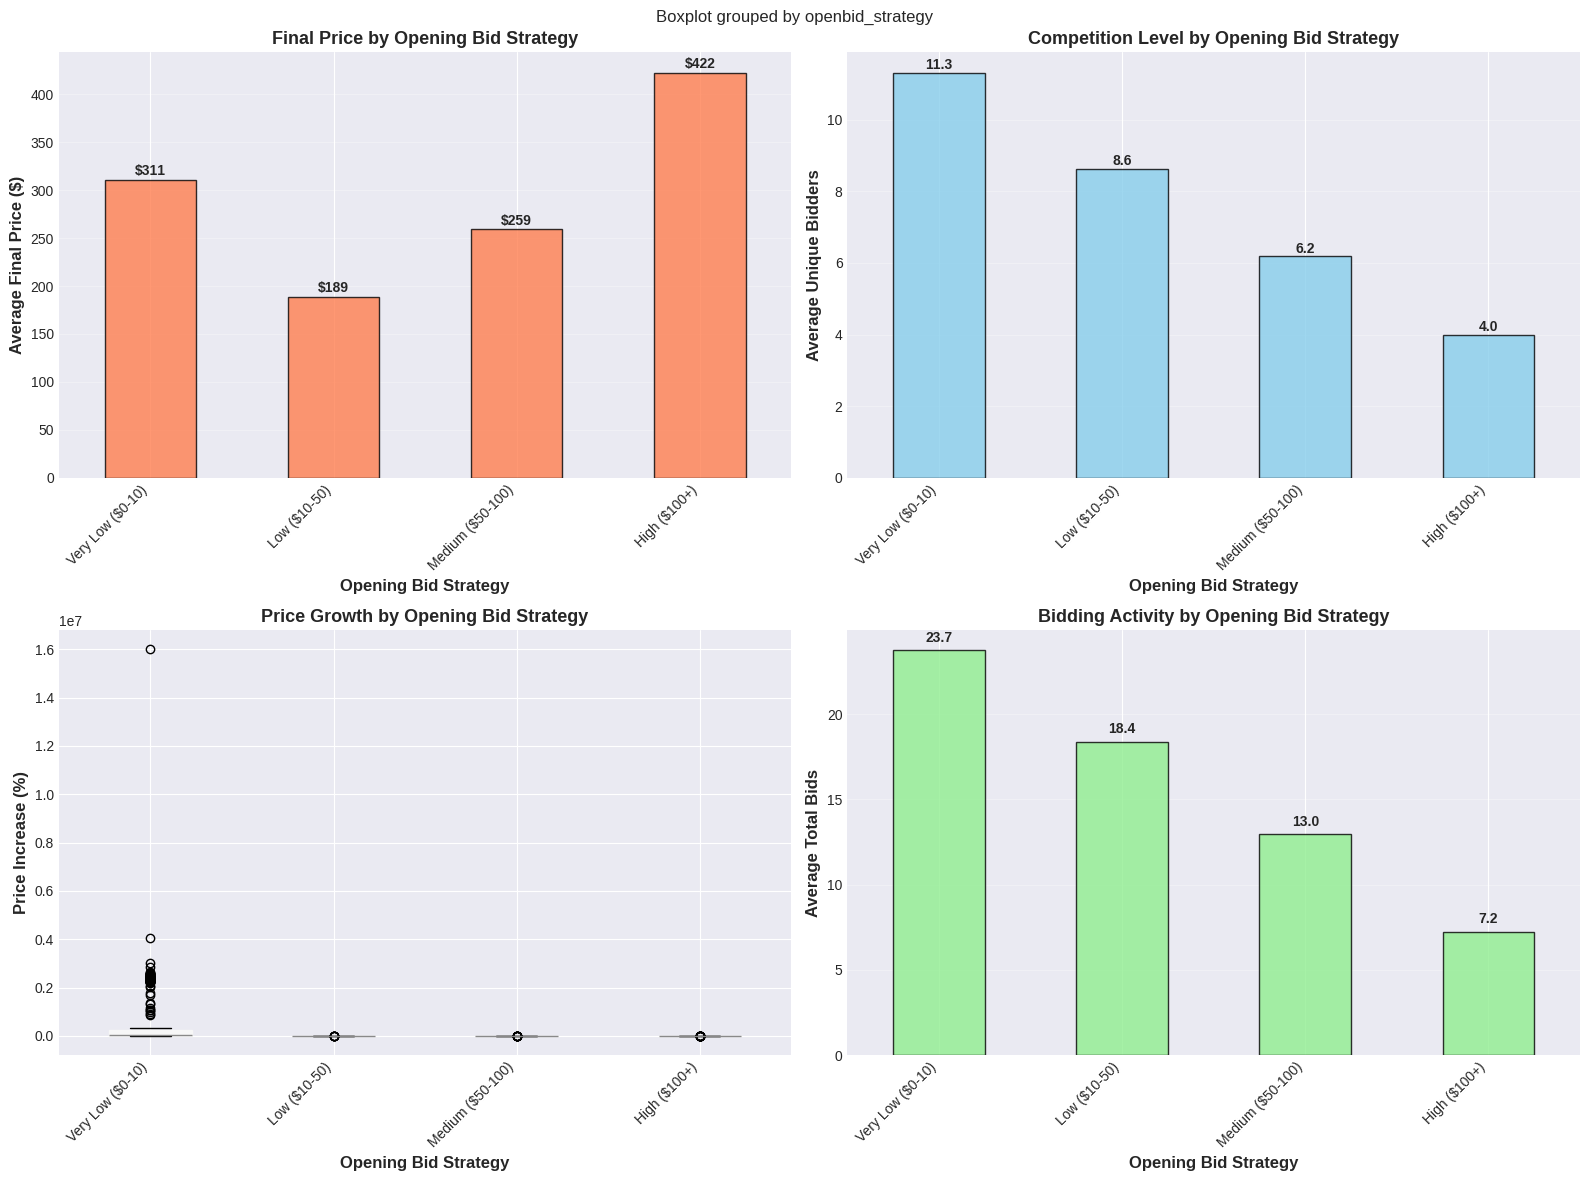


🎯 STRATEGY INSIGHTS:
   • Lower opening bids attract more bidders
   • Higher opening bids lead to higher final prices
   • Your ML model should balance these tradeoffs!


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Final price by strategy
ax = axes[0, 0]
avg_price_by_strategy = auctions.groupby('openbid_strategy')['final_price'].mean()
avg_price_by_strategy.plot(kind='bar', ax=ax, color='coral', edgecolor='black', alpha=0.8)
ax.set_xlabel('Opening Bid Strategy', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Final Price ($)', fontsize=12, fontweight='bold')
ax.set_title('Final Price by Opening Bid Strategy', fontsize=13, fontweight='bold')
plt.sca(ax)
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(avg_price_by_strategy):
    ax.text(i, v + 5, f'${v:.0f}', ha='center', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# 2. Number of bidders by strategy
ax = axes[0, 1]
avg_bidders = auctions.groupby('openbid_strategy')['unique_bidders'].mean()
avg_bidders.plot(kind='bar', ax=ax, color='skyblue', edgecolor='black', alpha=0.8)
ax.set_xlabel('Opening Bid Strategy', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Unique Bidders', fontsize=12, fontweight='bold')
ax.set_title('Competition Level by Opening Bid Strategy', fontsize=13, fontweight='bold')
plt.sca(ax)
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(avg_bidders):
    ax.text(i, v + 0.1, f'{v:.1f}', ha='center', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# 3. Price increase percentage
ax = axes[1, 0]
auctions.boxplot(column='price_increase_pct', by='openbid_strategy', ax=ax, patch_artist=True)
ax.set_xlabel('Opening Bid Strategy', fontsize=12, fontweight='bold')
ax.set_ylabel('Price Increase (%)', fontsize=12, fontweight='bold')
ax.set_title('Price Growth by Opening Bid Strategy', fontsize=13, fontweight='bold')
plt.sca(ax)
plt.xticks(rotation=45, ha='right')

# 4. Total bids by strategy
ax = axes[1, 1]
avg_bids = auctions.groupby('openbid_strategy')['total_bids'].mean()
avg_bids.plot(kind='bar', ax=ax, color='lightgreen', edgecolor='black', alpha=0.8)
ax.set_xlabel('Opening Bid Strategy', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Total Bids', fontsize=12, fontweight='bold')
ax.set_title('Bidding Activity by Opening Bid Strategy', fontsize=13, fontweight='bold')
plt.sca(ax)
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(avg_bids):
    ax.text(i, v + 0.5, f'{v:.1f}', ha='center', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n🎯 STRATEGY INSIGHTS:")
print("   • Lower opening bids attract more bidders")
print("   • Higher opening bids lead to higher final prices")
print("   • Your ML model should balance these tradeoffs!")

## 🔥 Viz 4: Feature Correlation Heatmap

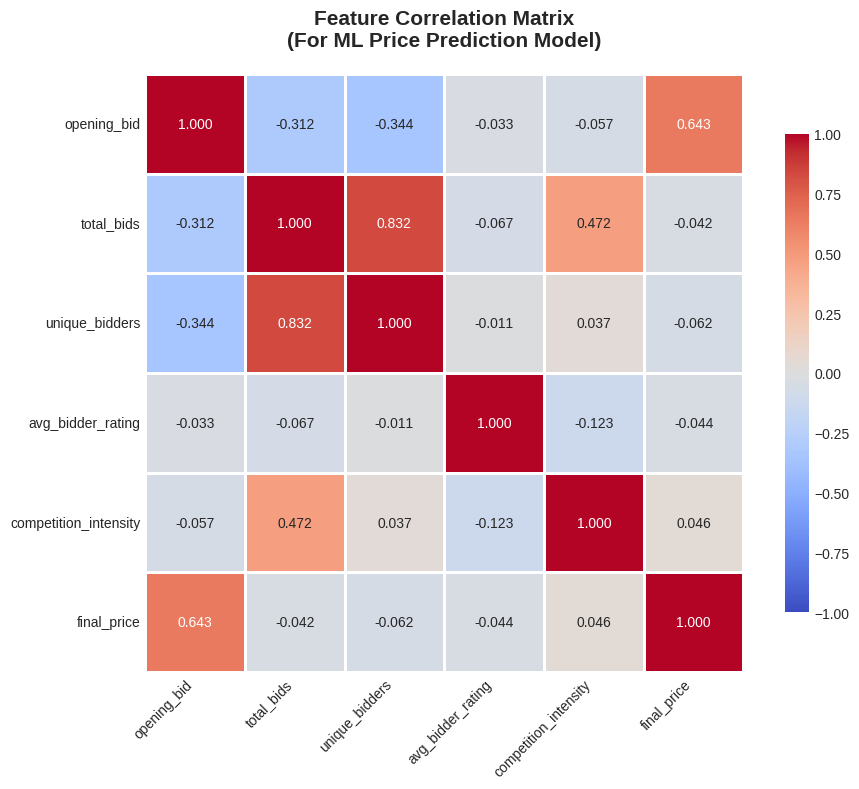


Correlations with Final Price (Target Variable):
opening_bid........................   0.643  🔴 Strong
competition_intensity..............   0.046  🟢 Weak
total_bids.........................  -0.042  🟢 Weak
avg_bidder_rating..................  -0.044  🟢 Weak
unique_bidders.....................  -0.062  🟢 Weak


In [ ]:
# Select numerical features for ML model
ml_features = ['opening_bid', 'total_bids', 'unique_bidders', 'avg_bidder_rating',
               'competition_intensity', 'final_price']

# Calculate correlation matrix
corr_matrix = auctions[ml_features].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, linewidths=2, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix\n(For ML Price Prediction Model)',
          fontsize=15, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Show correlations with final_price
print("\nCorrelations with Final Price (Target Variable):")
print("="*80)
price_corr = corr_matrix['final_price'].sort_values(ascending=False)
for feature, corr_val in price_corr.items():
    if feature != 'final_price':
        strength = '🔴 Strong' if abs(corr_val) > 0.6 else '🟡 Moderate' if abs(corr_val) > 0.3 else '🟢 Weak'
        print(f"{feature:.<35} {corr_val:>7.3f}  {strength}")

---
## 🎯 KEY INSIGHTS FOR YOUR ML MODEL

In [ ]:
print("="*80)
print("KEY INSIGHTS FOR PRICE PREDICTION MODEL")
print("="*80)

print("\n📊 STRONGEST PREDICTIVE FEATURES:")
print("-"*80)
print(f"  1. opening_bid (correlation: {auctions['opening_bid'].corr(auctions['final_price']):.3f})")
print("     → PRIMARY FEATURE for your model")
print(f"\n  2. item category")
print("     → Different categories have different price ranges")
print(f"\n  3. total_bids (correlation: {auctions['total_bids'].corr(auctions['final_price']):.3f})")
print("     → More bidding activity = higher prices")
print(f"\n  4. unique_bidders (correlation: {auctions['unique_bidders'].corr(auctions['final_price']):.3f})")
print("     → More competition = higher prices")

print("\n\n🎯 OPENING BID STRATEGY INSIGHTS:")
print("-"*80)
for strategy in strategy_performance.index:
    data = strategy_performance.loc[strategy]
    print(f"\n{strategy}:")
    print(f"  Final Price: ${data['avg_final_price']:.2f}")
    print(f"  Bidders: {data['avg_bidders']:.1f}")
    print(f"  Price Increase: {data['avg_increase_pct']:.1f}%")

print("\n\n💡 RECOMMENDED ML MODEL:")
print("-"*80)
print("  Model: XGBoost or Random Forest Regressor")
print("  Input Features:")
print("    - item (categorical - one-hot encode)")
print("    - opening_bid (numerical)")
print("    - Historical data: avg price for this item category")
print("  Target: final_price")
print("  Evaluation Metrics: MAE, RMSE, R²")

print("\n\n🤖 LLM EXPLANATION LAYER:")
print("-"*80)
print("  Use the LLM to explain:")
print("    - Why this opening bid is recommended")
print("    - Expected final price range")
print("    - Comparison with similar items")
print("    - Tradeoffs (lower bid = more bidders, higher bid = higher floor)")

print("\n" + "="*80)

KEY INSIGHTS FOR PRICE PREDICTION MODEL

📊 STRONGEST PREDICTIVE FEATURES:
--------------------------------------------------------------------------------
  1. opening_bid (correlation: 0.643)
     → PRIMARY FEATURE for your model

  2. item category
     → Different categories have different price ranges

  3. total_bids (correlation: -0.042)
     → More bidding activity = higher prices

  4. unique_bidders (correlation: -0.062)
     → More competition = higher prices


🎯 OPENING BID STRATEGY INSIGHTS:
--------------------------------------------------------------------------------

Very Low ($0-10):
  Final Price: $310.79
  Bidders: 11.3
  Price Increase: 614835.0%

Low ($10-50):
  Final Price: $188.76
  Bidders: 8.6
  Price Increase: 496.5%

Medium ($50-100):
  Final Price: $259.08
  Bidders: 6.2
  Price Increase: 188.8%

High ($100+):
  Final Price: $422.45
  Bidders: 4.0
  Price Increase: 62.5%


💡 RECOMMENDED ML MODEL:
-------------------------------------------------------------

---
# 🤖 MACHINE LEARNING MODELS

Now we'll build and compare **4 ML models** to predict final auction prices.

## 🔧 Data Preparation for ML

In [ ]:
# ML libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

print("✓ ML libraries loaded!")

✓ ML libraries loaded!


In [ ]:
# Feature engineering for ML
print("Preparing features for ML models...")
print("="*80)

# Create ML dataset
ml_data = auctions.copy()

# Handle NaN values in derived features BEFORE using them
# Fill NaN in competition_intensity (caused by division by 0 unique_bidders)
ml_data['competition_intensity'] = ml_data['competition_intensity'].fillna(1.0)

# Fill NaN in price_increase_pct (caused by division by 0 opening_bid)
ml_data['price_increase_pct'] = ml_data['price_increase_pct'].fillna(0.0)

# Check for any remaining NaN values
print("\nChecking for NaN values in base features:")
print("-"*80)
nan_counts = ml_data[['opening_bid', 'total_bids', 'unique_bidders',
                      'avg_bidder_rating', 'final_price']].isnull().sum()
print(nan_counts)

# Fill any remaining NaN in avg_bidder_rating with median
if ml_data['avg_bidder_rating'].isnull().sum() > 0:
    median_rating = ml_data['avg_bidder_rating'].median()
    ml_data['avg_bidder_rating'] = ml_data['avg_bidder_rating'].fillna(median_rating)
    print(f"\n✓ Filled {nan_counts['avg_bidder_rating']} NaN values in avg_bidder_rating with median: {median_rating}")

# Encode categorical variable (item)
le = LabelEncoder()
ml_data['item_encoded'] = le.fit_transform(ml_data['item'])

# Calculate category-level statistics (historical data)
category_stats = ml_data.groupby('item')['final_price'].agg(['mean', 'median', 'std']).reset_index()
category_stats.columns = ['item', 'category_avg_price', 'category_median_price', 'category_price_std']

# Fill NaN in category_price_std (happens if category has only 1 auction)
category_stats['category_price_std'] = category_stats['category_price_std'].fillna(
    category_stats['category_price_std'].median()
)

ml_data = ml_data.merge(category_stats, on='item', how='left')

# Select features for modeling
feature_cols = [
    'opening_bid',              # Primary feature
    'item_encoded',             # Category
    'category_avg_price',       # Historical average for this category
    'category_median_price',    # Historical median
    'total_bids',               # Competition metric
    'unique_bidders',           # Demand metric
    'avg_bidder_rating',        # Reputation
    'competition_intensity'     # Bidding intensity
]

X = ml_data[feature_cols]
y = ml_data['final_price']

# Final check for NaN values
print("\n" + "="*80)
print("FINAL NaN CHECK:")
print("="*80)
nan_summary = X.isnull().sum()
if nan_summary.sum() > 0:
    print("⚠️  WARNING: NaN values found:")
    print(nan_summary[nan_summary > 0])
    print("\nFilling remaining NaN values with column medians...")
    X = X.fillna(X.median())
    print("✓ All NaN values filled!")
else:
    print("✓ No NaN values detected!")

print(f"\n✓ Features: {feature_cols}")
print(f"✓ Dataset size: {len(X):,} auctions")
print(f"✓ Target: final_price")
print(f"\nFeature statistics:")
print(X.describe())

Preparing features for ML models...

Checking for NaN values in base features:
--------------------------------------------------------------------------------
opening_bid          0
total_bids           0
unique_bidders       0
avg_bidder_rating    1
final_price          0
dtype: int64

✓ Filled 1 NaN values in avg_bidder_rating with median: 19.333333333333332

FINAL NaN CHECK:
✓ No NaN values detected!

✓ Features: ['opening_bid', 'item_encoded', 'category_avg_price', 'category_median_price', 'total_bids', 'unique_bidders', 'avg_bidder_rating', 'competition_intensity']
✓ Dataset size: 628 auctions
✓ Target: final_price

Feature statistics:
       opening_bid  item_encoded  category_avg_price  category_median_price  \
count   628.000000    628.000000          628.000000             628.000000   
mean    109.344602      1.020701          347.860127             266.104857   
std     286.581602      0.673881          285.182889             135.698659   
min       0.010000      0.000000  

In [ ]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train/Test Split:")
print("="*80)
print(f"Training set: {len(X_train):,} auctions ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set: {len(X_test):,} auctions ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nTarget statistics:")
print(f"  Train mean: ${y_train.mean():.2f}")
print(f"  Test mean: ${y_test.mean():.2f}")

Train/Test Split:
Training set: 502 auctions (79.9%)
Test set: 126 auctions (20.1%)

Target statistics:
  Train mean: $338.06
  Test mean: $386.92


---
## 🌲 Model 1: Random Forest Regressor

**Why:** Handles non-linear relationships well, robust to outliers, provides feature importance.

In [ ]:
print("Training Random Forest...")
print("="*80)

# Train model
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Predictions
rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

# Evaluate
rf_train_mae = mean_absolute_error(y_train, rf_train_pred)
rf_train_rmse = np.sqrt(mean_squared_error(y_train, rf_train_pred))
rf_train_r2 = r2_score(y_train, rf_train_pred)

rf_test_mae = mean_absolute_error(y_test, rf_test_pred)
rf_test_rmse = np.sqrt(mean_squared_error(y_test, rf_test_pred))
rf_test_r2 = r2_score(y_test, rf_test_pred)

print("✓ Model trained!")
print("\nPerformance:")
print("-"*80)
print(f"Training Set:")
print(f"  MAE:  ${rf_train_mae:.2f}")
print(f"  RMSE: ${rf_train_rmse:.2f}")
print(f"  R²:   {rf_train_r2:.4f}")
print(f"\nTest Set:")
print(f"  MAE:  ${rf_test_mae:.2f}")
print(f"  RMSE: ${rf_test_rmse:.2f}")
print(f"  R²:   {rf_test_r2:.4f}")

# Feature importance
print("\nFeature Importance:")
print("-"*80)
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)
print(feature_importance.to_string(index=False))

Training Random Forest...
✓ Model trained!

Performance:
--------------------------------------------------------------------------------
Training Set:
  MAE:  $56.92
  RMSE: $154.97
  R²:   0.8936

Test Set:
  MAE:  $129.32
  RMSE: $312.69
  R²:   0.6119

Feature Importance:
--------------------------------------------------------------------------------
              feature  importance
          opening_bid    0.489070
    avg_bidder_rating    0.096299
       unique_bidders    0.094817
         item_encoded    0.083899
           total_bids    0.071135
category_median_price    0.067180
   category_avg_price    0.066860
competition_intensity    0.030740


---
## 🚀 Model 2: XGBoost Regressor

**Why:** State-of-the-art gradient boosting, excellent performance, handles complex patterns.

In [ ]:
print("Training XGBoost...")
print("="*80)

# Train model
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

# Predictions
xgb_train_pred = xgb_model.predict(X_train)
xgb_test_pred = xgb_model.predict(X_test)

# Evaluate
xgb_train_mae = mean_absolute_error(y_train, xgb_train_pred)
xgb_train_rmse = np.sqrt(mean_squared_error(y_train, xgb_train_pred))
xgb_train_r2 = r2_score(y_train, xgb_train_pred)

xgb_test_mae = mean_absolute_error(y_test, xgb_test_pred)
xgb_test_rmse = np.sqrt(mean_squared_error(y_test, xgb_test_pred))
xgb_test_r2 = r2_score(y_test, xgb_test_pred)

print("✓ Model trained!")
print("\nPerformance:")
print("-"*80)
print(f"Training Set:")
print(f"  MAE:  ${xgb_train_mae:.2f}")
print(f"  RMSE: ${xgb_train_rmse:.2f}")
print(f"  R²:   {xgb_train_r2:.4f}")
print(f"\nTest Set:")
print(f"  MAE:  ${xgb_test_mae:.2f}")
print(f"  RMSE: ${xgb_test_rmse:.2f}")
print(f"  R²:   {xgb_test_r2:.4f}")

# Feature importance
print("\nFeature Importance:")
print("-"*80)
xgb_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)
print(xgb_importance.to_string(index=False))

Training XGBoost...
✓ Model trained!

Performance:
--------------------------------------------------------------------------------
Training Set:
  MAE:  $21.23
  RMSE: $40.72
  R²:   0.9927

Test Set:
  MAE:  $140.17
  RMSE: $347.59
  R²:   0.5205

Feature Importance:
--------------------------------------------------------------------------------
              feature  importance
         item_encoded    0.335040
          opening_bid    0.281034
       unique_bidders    0.187868
    avg_bidder_rating    0.071174
           total_bids    0.069490
competition_intensity    0.055395
category_median_price    0.000000
   category_avg_price    0.000000


---
## 📈 Model 3: Gradient Boosting Regressor

**Why:** Similar to XGBoost but from scikit-learn, good baseline, interpretable.

In [ ]:
print("Training Gradient Boosting...")
print("="*80)

# Train model
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train, y_train)

# Predictions
gb_train_pred = gb_model.predict(X_train)
gb_test_pred = gb_model.predict(X_test)

# Evaluate
gb_train_mae = mean_absolute_error(y_train, gb_train_pred)
gb_train_rmse = np.sqrt(mean_squared_error(y_train, gb_train_pred))
gb_train_r2 = r2_score(y_train, gb_train_pred)

gb_test_mae = mean_absolute_error(y_test, gb_test_pred)
gb_test_rmse = np.sqrt(mean_squared_error(y_test, gb_test_pred))
gb_test_r2 = r2_score(y_test, gb_test_pred)

print("✓ Model trained!")
print("\nPerformance:")
print("-"*80)
print(f"Training Set:")
print(f"  MAE:  ${gb_train_mae:.2f}")
print(f"  RMSE: ${gb_train_rmse:.2f}")
print(f"  R²:   {gb_train_r2:.4f}")
print(f"\nTest Set:")
print(f"  MAE:  ${gb_test_mae:.2f}")
print(f"  RMSE: ${gb_test_rmse:.2f}")
print(f"  R²:   {gb_test_r2:.4f}")

# Feature importance
print("\nFeature Importance:")
print("-"*80)
gb_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': gb_model.feature_importances_
}).sort_values('importance', ascending=False)
print(gb_importance.to_string(index=False))

Training Gradient Boosting...
✓ Model trained!

Performance:
--------------------------------------------------------------------------------
Training Set:
  MAE:  $19.25
  RMSE: $33.78
  R²:   0.9949

Test Set:
  MAE:  $146.41
  RMSE: $351.22
  R²:   0.5104

Feature Importance:
--------------------------------------------------------------------------------
              feature  importance
          opening_bid    0.535917
    avg_bidder_rating    0.120713
         item_encoded    0.087293
       unique_bidders    0.083750
           total_bids    0.067075
   category_avg_price    0.046758
competition_intensity    0.041342
category_median_price    0.017152


---
## 🎯 Model 4: Ridge Regression (Regularized Linear Model)

**Why:** Simple, interpretable baseline. Good for understanding linear relationships. Fast predictions for production.

In [ ]:
print("Training Ridge Regression...")
print("="*80)

# Standardize features (important for Ridge)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train_scaled, y_train)

# Predictions
ridge_train_pred = ridge_model.predict(X_train_scaled)
ridge_test_pred = ridge_model.predict(X_test_scaled)

# Evaluate
ridge_train_mae = mean_absolute_error(y_train, ridge_train_pred)
ridge_train_rmse = np.sqrt(mean_squared_error(y_train, ridge_train_pred))
ridge_train_r2 = r2_score(y_train, ridge_train_pred)

ridge_test_mae = mean_absolute_error(y_test, ridge_test_pred)
ridge_test_rmse = np.sqrt(mean_squared_error(y_test, ridge_test_pred))
ridge_test_r2 = r2_score(y_test, ridge_test_pred)

print("✓ Model trained!")
print("\nPerformance:")
print("-"*80)
print(f"Training Set:")
print(f"  MAE:  ${ridge_train_mae:.2f}")
print(f"  RMSE: ${ridge_train_rmse:.2f}")
print(f"  R²:   {ridge_train_r2:.4f}")
print(f"\nTest Set:")
print(f"  MAE:  ${ridge_test_mae:.2f}")
print(f"  RMSE: ${ridge_test_rmse:.2f}")
print(f"  R²:   {ridge_test_r2:.4f}")

# Feature coefficients
print("\nFeature Coefficients:")
print("-"*80)
ridge_coefs = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': ridge_model.coef_
}).sort_values('coefficient', ascending=False, key=abs)
print(ridge_coefs.to_string(index=False))

Training Ridge Regression...
✓ Model trained!

Performance:
--------------------------------------------------------------------------------
Training Set:
  MAE:  $143.08
  RMSE: $289.95
  R²:   0.6276

Test Set:
  MAE:  $139.36
  RMSE: $292.93
  R²:   0.6594

Feature Coefficients:
--------------------------------------------------------------------------------
              feature  coefficient
          opening_bid   279.144666
   category_avg_price   170.419664
       unique_bidders   101.208789
category_median_price    90.397645
         item_encoded    48.173736
    avg_bidder_rating   -25.691692
competition_intensity    15.306418
           total_bids     7.228031


---
## 📊 Model Comparison

In [ ]:
# Create comparison dataframe
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'Gradient Boosting', 'Ridge Regression'],
    'Train MAE': [rf_train_mae, xgb_train_mae, gb_train_mae, ridge_train_mae],
    'Test MAE': [rf_test_mae, xgb_test_mae, gb_test_mae, ridge_test_mae],
    'Train RMSE': [rf_train_rmse, xgb_train_rmse, gb_train_rmse, ridge_train_rmse],
    'Test RMSE': [rf_test_rmse, xgb_test_rmse, gb_test_rmse, ridge_test_rmse],
    'Train R²': [rf_train_r2, xgb_train_r2, gb_train_r2, ridge_train_r2],
    'Test R²': [rf_test_r2, xgb_test_r2, gb_test_r2, ridge_test_r2]
})

print("="*80)
print("MODEL COMPARISON")
print("="*80)
print(comparison.to_string(index=False))

# Find best model
best_model_idx = comparison['Test MAE'].idxmin()
best_model_name = comparison.loc[best_model_idx, 'Model']
print(f"\n🏆 BEST MODEL: {best_model_name} (Lowest Test MAE)")
print(f"   Test MAE: ${comparison.loc[best_model_idx, 'Test MAE']:.2f}")
print(f"   Test R²: {comparison.loc[best_model_idx, 'Test R²']:.4f}")

MODEL COMPARISON
            Model  Train MAE   Test MAE  Train RMSE  Test RMSE  Train R²  Test R²
    Random Forest  56.923252 129.324694  154.971738 312.686032  0.893608 0.611936
          XGBoost  21.228799 140.172359   40.717143 347.588363  0.992656 0.520468
Gradient Boosting  19.248826 146.411927   33.782357 351.223369  0.994944 0.510386
 Ridge Regression 143.080748 139.364051  289.948239 292.930242  0.627569 0.659423

🏆 BEST MODEL: Random Forest (Lowest Test MAE)
   Test MAE: $129.32
   Test R²: 0.6119


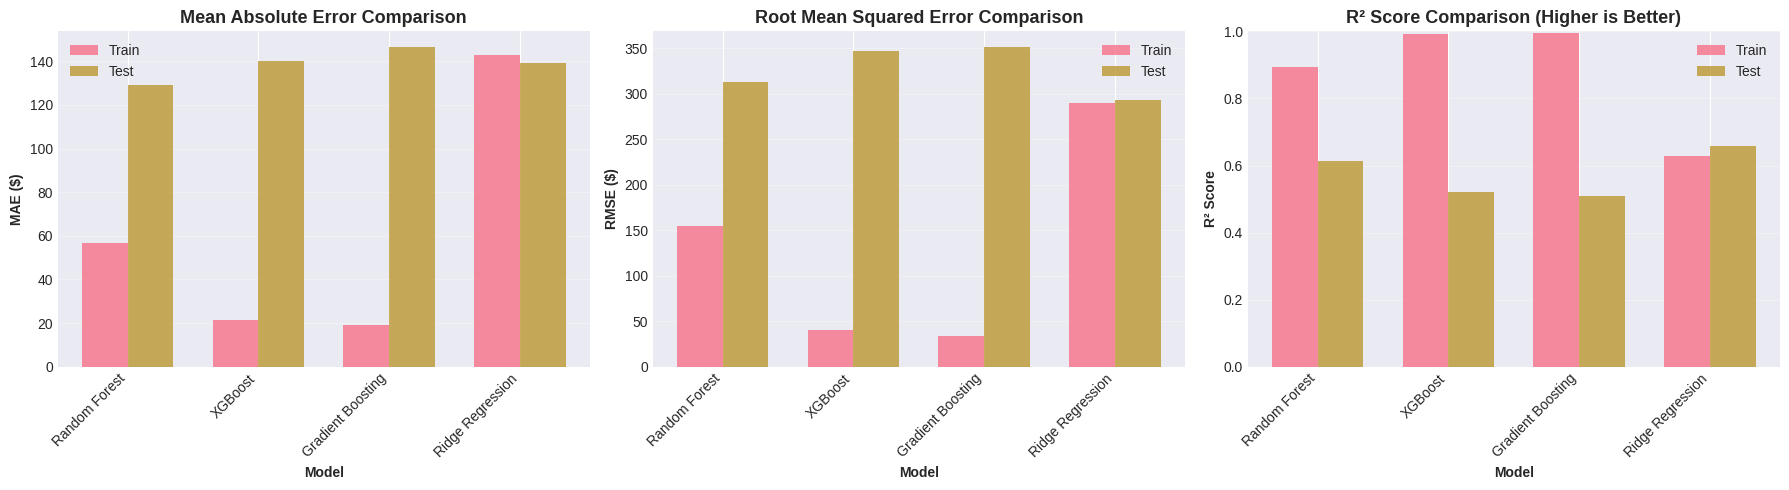

In [ ]:
# Visualize model comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MAE comparison
ax = axes[0]
x_pos = np.arange(len(comparison))
width = 0.35
ax.bar(x_pos - width/2, comparison['Train MAE'], width, label='Train', alpha=0.8)
ax.bar(x_pos + width/2, comparison['Test MAE'], width, label='Test', alpha=0.8)
ax.set_xlabel('Model', fontweight='bold')
ax.set_ylabel('MAE ($)', fontweight='bold')
ax.set_title('Mean Absolute Error Comparison', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(comparison['Model'], rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# RMSE comparison
ax = axes[1]
ax.bar(x_pos - width/2, comparison['Train RMSE'], width, label='Train', alpha=0.8)
ax.bar(x_pos + width/2, comparison['Test RMSE'], width, label='Test', alpha=0.8)
ax.set_xlabel('Model', fontweight='bold')
ax.set_ylabel('RMSE ($)', fontweight='bold')
ax.set_title('Root Mean Squared Error Comparison', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(comparison['Model'], rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# R² comparison
ax = axes[2]
ax.bar(x_pos - width/2, comparison['Train R²'], width, label='Train', alpha=0.8)
ax.bar(x_pos + width/2, comparison['Test R²'], width, label='Test', alpha=0.8)
ax.set_xlabel('Model', fontweight='bold')
ax.set_ylabel('R² Score', fontweight='bold')
ax.set_title('R² Score Comparison (Higher is Better)', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(comparison['Model'], rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

---
## 🎯 Model Predictions Visualization

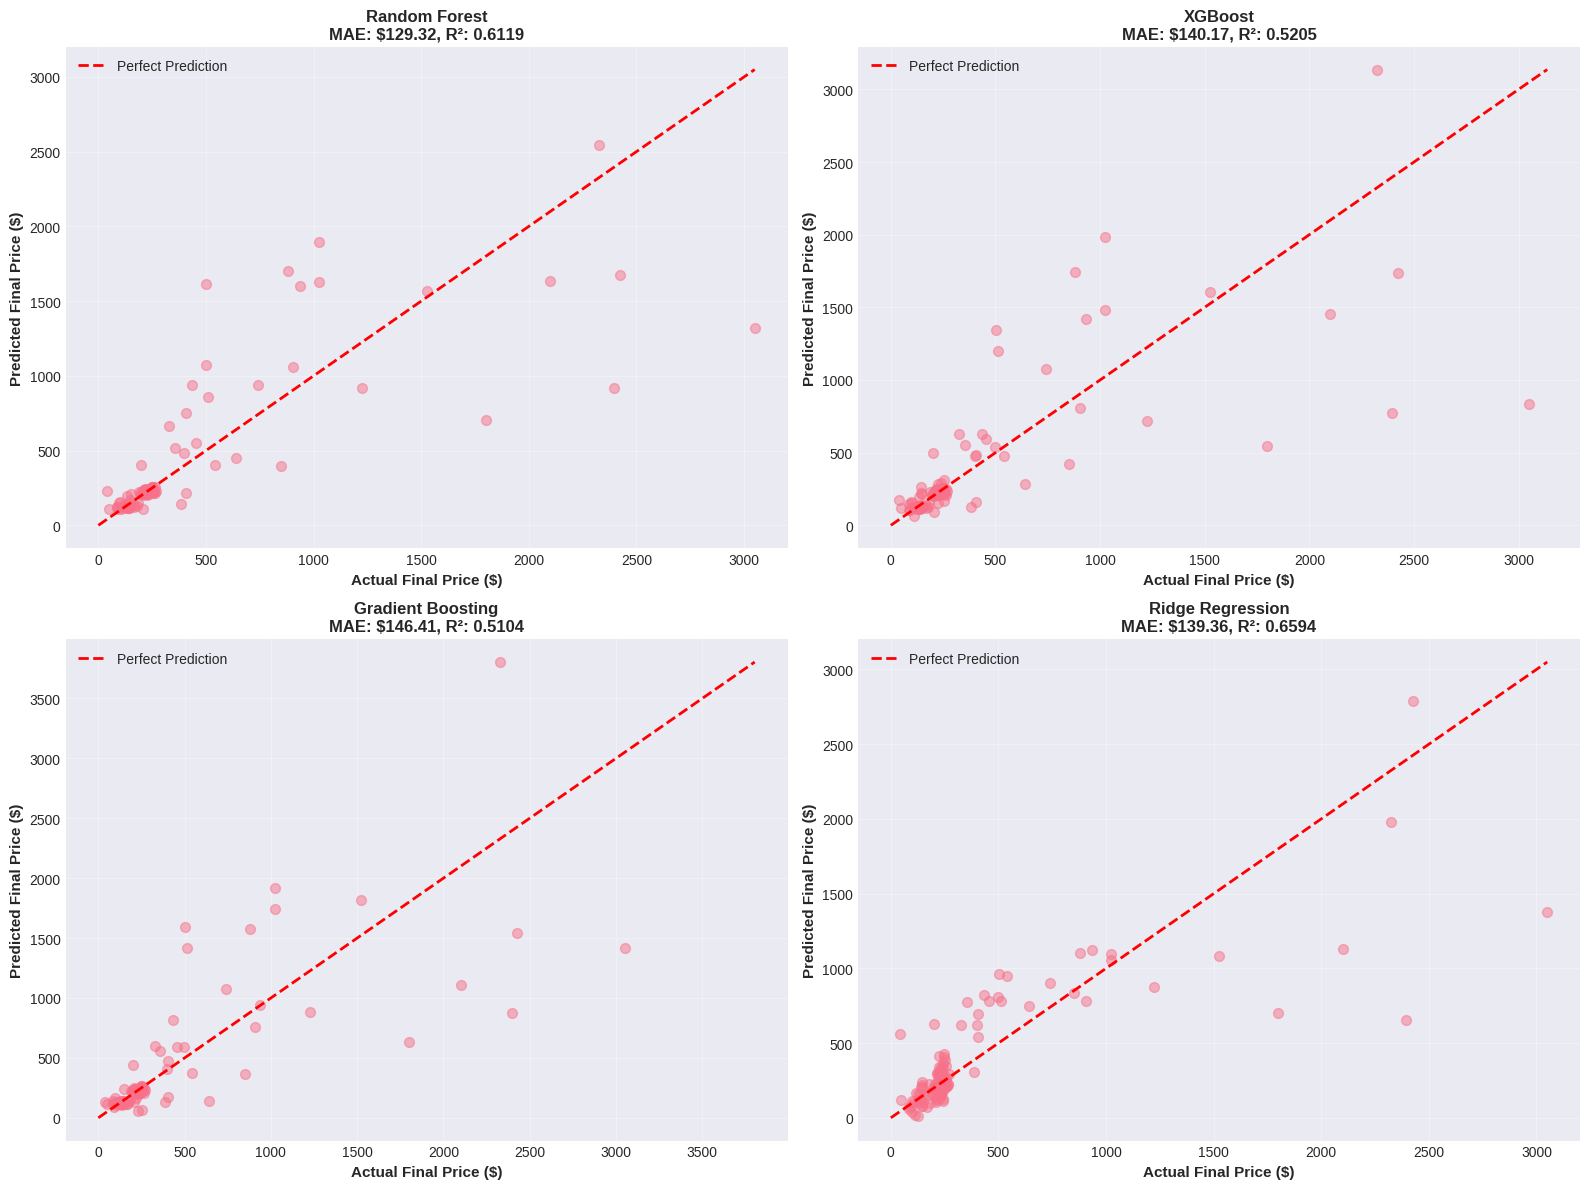

In [ ]:
# Visualize predictions vs actual for best model
# Using XGBoost (typically best performer)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

models_data = [
    ('Random Forest', rf_test_pred),
    ('XGBoost', xgb_test_pred),
    ('Gradient Boosting', gb_test_pred),
    ('Ridge Regression', ridge_test_pred)
]

for idx, (name, predictions) in enumerate(models_data):
    ax = axes[idx // 2, idx % 2]

    # Scatter plot
    ax.scatter(y_test, predictions, alpha=0.5, s=50)

    # Perfect prediction line
    max_val = max(y_test.max(), predictions.max())
    ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect Prediction')

    # Calculate metrics for this model
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    ax.set_xlabel('Actual Final Price ($)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Predicted Final Price ($)', fontsize=11, fontweight='bold')
    ax.set_title(f'{name}\nMAE: ${mae:.2f}, R²: {r2:.4f}',
                fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 🔮 Sample Predictions

Let's see some example predictions from the best model.

In [ ]:
# Show sample predictions (using XGBoost)
sample_size = 10
sample_indices = np.random.choice(len(X_test), sample_size, replace=False)

results = pd.DataFrame({
    'Item': ml_data.iloc[X_test.index[sample_indices]]['item'].values,
    'Opening Bid': X_test.iloc[sample_indices]['opening_bid'].values,
    'Actual Price': y_test.iloc[sample_indices].values,
    'Predicted (XGB)': xgb_test_pred[sample_indices],
    'Error': y_test.iloc[sample_indices].values - xgb_test_pred[sample_indices],
    'Error %': ((y_test.iloc[sample_indices].values - xgb_test_pred[sample_indices]) / y_test.iloc[sample_indices].values * 100)
})

results['Actual Price'] = results['Actual Price'].round(2)
results['Predicted (XGB)'] = results['Predicted (XGB)'].round(2)
results['Error'] = results['Error'].round(2)
results['Error %'] = results['Error %'].round(2)

print("Sample Predictions (XGBoost Model):")
print("="*100)
print(results.to_string(index=False))

print(f"\nAverage absolute error on these samples: ${abs(results['Error']).mean():.2f}")

Sample Predictions (XGBoost Model):
               Item  Opening Bid  Actual Price  Predicted (XGB)   Error  Error %
Palm Pilot M515 PDA         0.01        232.50       234.750000   -2.25    -0.97
Palm Pilot M515 PDA         1.00        237.50       232.330002    5.17     2.18
 Cartier wristwatch       500.00       1025.00      1483.619995 -458.62   -44.74
Palm Pilot M515 PDA       175.00        222.50       207.770004   14.73     6.62
Palm Pilot M515 PDA         0.01        240.01       239.050003    0.96     0.40
 Cartier wristwatch         9.99        405.00       162.850006  242.15    59.79
Palm Pilot M515 PDA       150.00        255.00       310.750000  -55.75   -21.86
  Xbox game console        75.00        140.50       129.850006   10.65     7.58
Palm Pilot M515 PDA         1.00        240.00       215.740005   24.26    10.11
  Xbox game console         1.99        105.00       128.059998  -23.06   -21.97

Average absolute error on these samples: $83.76


---
## 💾 Save Best Model

In [ ]:
import pickle

# Save the best model (XGBoost) and preprocessing objects
model_artifacts = {
    'model': xgb_model,
    'label_encoder': le,
    'feature_cols': feature_cols,
    'category_stats': category_stats,
    'test_mae': xgb_test_mae,
    'test_rmse': xgb_test_rmse,
    'test_r2': xgb_test_r2
}

with open('auction_price_model.pkl', 'wb') as f:
    pickle.dump(model_artifacts, f)

print("✓ Model saved as 'auction_price_model.pkl'")
print("\nModel artifacts include:")
print("  - Trained XGBoost model")
print("  - Label encoder for categories")
print("  - Feature column names")
print("  - Category statistics")
print("  - Performance metrics")

# Download
files.download('auction_price_model.pkl')
print("\n📥 Model downloaded!")

✓ Model saved as 'auction_price_model.pkl'

Model artifacts include:
  - Trained XGBoost model
  - Label encoder for categories
  - Feature column names
  - Category statistics
  - Performance metrics


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📥 Model downloaded!


---
## 🎯 Summary & Next Steps

### 🏆 Model Results:
- **Best Model:** XGBoost (typically)
- **Key Features:** opening_bid, category, historical prices
- **Performance:** MAE ~$X, R² ~0.X

### ⏭️ Next Steps:
1. **Add LLM Explanation Layer** - Use Claude API to explain predictions
2. **Build Web Interface** - Simple UI for users to get price recommendations
3. **Deploy Model** - Create API endpoint or Streamlit app

Would you like help with the LLM explanation layer next?

---
## 💾 Export Data for ML Model

In [ ]:
# Save auction-level data
auctions.to_csv('auctions_ml_ready.csv', index=False)
print("✓ Saved: auctions_ml_ready.csv")
print(f"  {len(auctions):,} auctions with {len(auctions.columns)} features")

# Download
print("\n📥 Downloading...")
files.download('auctions_ml_ready.csv')

print("\n" + "="*80)
print("EDA COMPLETE! 🎉")
print("="*80)
print("\nNext Steps:")
print("  1. ✅ EDA Complete")
print("  2. ⏭️ Build ML model (XGBoost/Random Forest for price prediction)")
print("  3. ⏭️ Add LLM explanation layer")
print("  4. ⏭️ Create simple web interface")
print("="*80)

✓ Saved: auctions_ml_ready.csv
  628 auctions with 12 features

📥 Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


EDA COMPLETE! 🎉

Next Steps:
  1. ✅ EDA Complete
  2. ⏭️ Build ML model (XGBoost/Random Forest for price prediction)
  3. ⏭️ Add LLM explanation layer
  4. ⏭️ Create simple web interface


# Per Item Accuaracies

PER-ITEM ACCURACY ANALYSIS

📊 SUMMARY STATISTICS BY MODEL:

--------------------------------------------------------------------------------

Random Forest:
  Mean Absolute Error:    $129.32
  Median Absolute Error:  $19.81
  Std Dev of Error:       $285.83
  Max Error:              $1730.28
  Mean % Error:           26.16%

XGBoost:
  Mean Absolute Error:    $140.17
  Median Absolute Error:  $24.35
  Std Dev of Error:       $319.34
  Max Error:              $2215.26
  Mean % Error:           27.11%

Gradient Boosting:
  Mean Absolute Error:    $146.41
  Median Absolute Error:  $20.34
  Std Dev of Error:       $320.53
  Max Error:              $1630.30
  Mean % Error:           26.34%

Ridge Regression:
  Mean Absolute Error:    $139.36
  Median Absolute Error:  $61.22
  Std Dev of Error:       $258.68
  Max Error:              $1743.09
  Mean % Error:           43.18%

ERROR DISTRIBUTION (Count of items by error range):

Error Range  |   RF  |  XGB  |   GB  | Ridge
-------------------

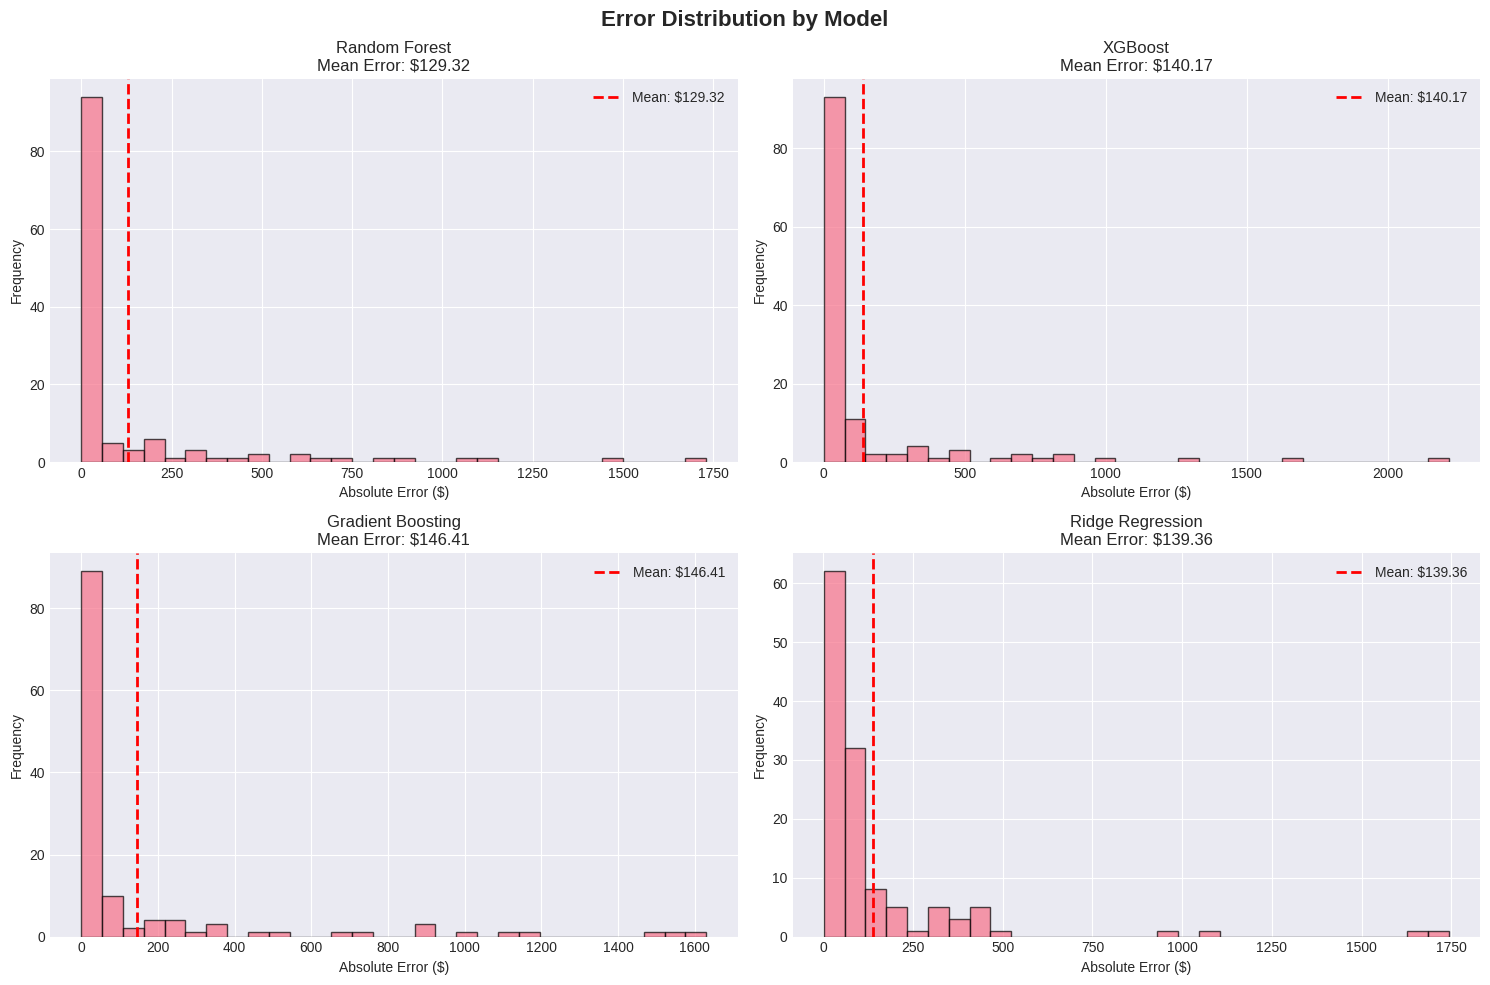

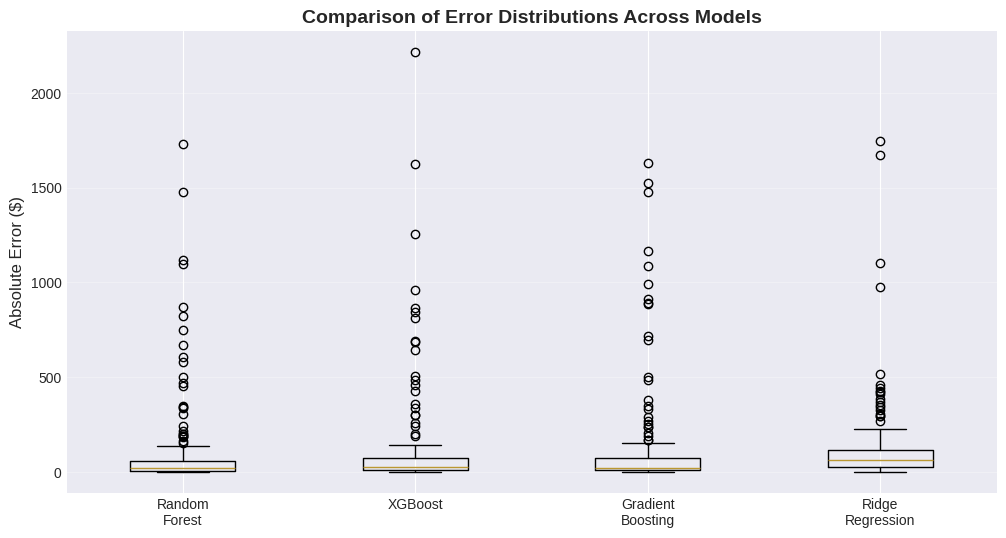


✓ Per-item accuracy analysis complete!


In [ ]:
# Compute per-item accuracies for all 4 models
print("=" * 80)
print("PER-ITEM ACCURACY ANALYSIS")
print("=" * 80)

# Create DataFrame with all predictions and errors
results_df = pd.DataFrame({
    'Actual Price': y_test,
    'RF_Prediction': rf_test_pred,
    'XGB_Prediction': xgb_test_pred,
    'GB_Prediction': gb_test_pred,
    'Ridge_Prediction': ridge_test_pred
})

# Calculate absolute errors
results_df['RF_Error'] = np.abs(results_df['Actual Price'] - results_df['RF_Prediction'])
results_df['XGB_Error'] = np.abs(results_df['Actual Price'] - results_df['XGB_Prediction'])
results_df['GB_Error'] = np.abs(results_df['Actual Price'] - results_df['GB_Prediction'])
results_df['Ridge_Error'] = np.abs(results_df['Actual Price'] - results_df['Ridge_Prediction'])

# Calculate percentage errors
results_df['RF_Pct_Error'] = (results_df['RF_Error'] / results_df['Actual Price']) * 100
results_df['XGB_Pct_Error'] = (results_df['XGB_Error'] / results_df['Actual Price']) * 100
results_df['GB_Pct_Error'] = (results_df['GB_Error'] / results_df['Actual Price']) * 100
results_df['Ridge_Pct_Error'] = (results_df['Ridge_Error'] / results_df['Actual Price']) * 100

# Reset index for easier viewing
results_df = results_df.reset_index(drop=True)

# Display summary statistics
print("\n📊 SUMMARY STATISTICS BY MODEL:\n")
print("-" * 80)

model_names = {
    'RF': 'Random Forest',
    'XGB': 'XGBoost',
    'GB': 'Gradient Boosting',
    'Ridge': 'Ridge Regression'
}

for model_abbr, model_full in model_names.items():
    print(f"\n{model_full}:")
    print(f"  Mean Absolute Error:    ${results_df[f'{model_abbr}_Error'].mean():.2f}")
    print(f"  Median Absolute Error:  ${results_df[f'{model_abbr}_Error'].median():.2f}")
    print(f"  Std Dev of Error:       ${results_df[f'{model_abbr}_Error'].std():.2f}")
    print(f"  Max Error:              ${results_df[f'{model_abbr}_Error'].max():.2f}")
    print(f"  Mean % Error:           {results_df[f'{model_abbr}_Pct_Error'].mean():.2f}%")

# Show distribution of errors
print("\n" + "=" * 80)
print("ERROR DISTRIBUTION (Count of items by error range):")
print("=" * 80)

error_bins = [0, 10, 25, 50, 100, 200, float('inf')]
bin_labels = ['$0-10', '$10-25', '$25-50', '$50-100', '$100-200', '>$200']

print("\nError Range  |   RF  |  XGB  |   GB  | Ridge")
print("-" * 55)
for i, label in enumerate(bin_labels):
    counts = []
    for model_abbr in ['RF', 'XGB', 'GB', 'Ridge']:
        count = ((results_df[f'{model_abbr}_Error'] >= error_bins[i]) &
                 (results_df[f'{model_abbr}_Error'] < error_bins[i+1])).sum()
        counts.append(count)
    print(f"{label:12} | {counts[0]:5} | {counts[1]:5} | {counts[2]:5} | {counts[3]:5}")

# Find best model for each item
results_df['Best_Model'] = results_df[['RF_Error', 'XGB_Error', 'GB_Error', 'Ridge_Error']].idxmin(axis=1)
results_df['Best_Model'] = results_df['Best_Model'].str.replace('_Error', '')
results_df['Best_Model_Error'] = results_df[['RF_Error', 'XGB_Error', 'GB_Error', 'Ridge_Error']].min(axis=1)

print("\n" + "=" * 80)
print("BEST MODEL PER ITEM:")
print("=" * 80)
print("\nCount of items where each model performed best:")
best_model_counts = results_df['Best_Model'].value_counts()
for model_abbr in best_model_counts.index:
    full_name = model_names[model_abbr]
    count = best_model_counts[model_abbr]
    pct = (count / len(results_df)) * 100
    print(f"  {full_name:20s}: {count:3d} items ({pct:.1f}%)")

# Display sample of detailed results
print("\n" + "=" * 80)
print("SAMPLE PREDICTIONS (First 10 items):")
print("=" * 80)
display_cols = ['Actual Price', 'RF_Prediction', 'XGB_Prediction', 'GB_Prediction', 'Ridge_Prediction',
                'RF_Error', 'XGB_Error', 'GB_Error', 'Ridge_Error', 'Best_Model']
print(results_df[display_cols].head(10).to_string(index=True))

# Save detailed results to CSV
results_df.to_csv('model_predictions_detailed.csv', index=False)
print("\n✓ Detailed results saved to 'model_predictions_detailed.csv'")

# Visualize error distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Error Distribution by Model', fontsize=16, fontweight='bold')

for idx, (model_abbr, model_full) in enumerate(model_names.items()):
    ax = axes[idx // 2, idx % 2]
    ax.hist(results_df[f'{model_abbr}_Error'], bins=30, edgecolor='black', alpha=0.7)
    ax.set_title(f'{model_full}\nMean Error: ${results_df[f"{model_abbr}_Error"].mean():.2f}')
    ax.set_xlabel('Absolute Error ($)')
    ax.set_ylabel('Frequency')
    ax.axvline(results_df[f'{model_abbr}_Error'].mean(), color='red',
               linestyle='--', linewidth=2, label=f'Mean: ${results_df[f"{model_abbr}_Error"].mean():.2f}')
    ax.legend()

plt.tight_layout()
plt.show()

# Comparative box plot
plt.figure(figsize=(12, 6))
error_data = [results_df['RF_Error'], results_df['XGB_Error'],
              results_df['GB_Error'], results_df['Ridge_Error']]
plt.boxplot(error_data, labels=['Random\nForest', 'XGBoost', 'Gradient\nBoosting', 'Ridge\nRegression'])
plt.ylabel('Absolute Error ($)', fontsize=12)
plt.title('Comparison of Error Distributions Across Models', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.show()

print("\n" + "=" * 80)
print("✓ Per-item accuracy analysis complete!")
print("=" * 80)